# **Effects of Alcohol on Student Performance**

datset tmado de kaggle https://www.kaggle.com/datasets/joshuanaude/effects-of-alcohol-on-student-performance


In [1]:
# Cargamos las librerias becesarias para la exloración

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =========================
# CONFIGURACIÓN SEABORN
# =========================
sns.set_theme(
    context="notebook",      # paper, notebook, talk, poster
    style="whitegrid",       # white, dark, whitegrid, darkgrid, ticks
    palette="deep",          # deep, muted, bright, pastel, dark, colorblind
    font="serif",
    font_scale=1.2
)


In [3]:
# establecemos la ruta del dataset (.csv) en Drive
from google.colab import drive
drive.mount("/content/drive")

ruta = "/content/drive/MyDrive/MAESTRIA_CIENCIA_DE_DATOS/data-sets/raw_data/Alcohol-on-Student -Performance.csv"

df = pd.read_csv(ruta)
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Timestamp,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly Allowance in 2023,Were you on scholarship/bursary in 2023?,Additional amount of studying (in hrs) per week,How often do you go out partying/socialising during the week?,"On a night out, how many alcoholic drinks do you consume?","How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",How many modules have you failed thus far into your studies?,Are you currently in a romantic relationship?,Do your parents approve alcohol consumption?,How strong is your relationship with your parent/s?
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,2024/03/12 11:05:33 am EET,Female,74.0,NaN,Science,NaN,Private accommodation/ stay with family/friends,NaN,No,3-5,3,1-3,0,0,No,Yes,Close
402,2024/03/12 3:26:14 pm EET,Female,73.0,2nd Year,Economic & Management Sciences,58.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,"Yes (NSFAS, etc...)",5-8,1,8+,0,0,Yes,Yes,Very close
403,2024/03/13 10:32:19 pm EET,Female,86.0,1st Year,NaN,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,No,5-8,2,3-5,1,0,No,Yes,Very close
404,2024/03/13 10:32:27 pm EET,Male,85.0,NaN,Economic & Management Sciences,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,No,1-3,4+,5-8,4+,0,No,Yes,Close


## **Vamos a obtener información general del datset**


In [4]:
# dimensión del datset
filas, cols = df.shape
print(f"El datset tien {filas} filas y {cols} columas")

El datset tien 406 filas y 17 columas


#### **Tipo de variable**

Verifiquemios el tipo de cada una de las variables

In [5]:
# Veams el tipo de variables
df.dtypes

,0
Timestamp,object
Your Sex?,object
Your Matric (grade 12) Average/ GPA (in %),float64
What year were you in last year (2023) ?,object
What faculty does your degree fall under?,object
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),float64
Your Accommodation Status Last Year (2023),object
Monthly Allowance in 2023,object
Were you on scholarship/bursary in 2023?,object
Additional amount of studying (in hrs) per week,object


Se puede observar:

 - Nombres de las variables son extensos ya que  corresponde a preguntas de caracter personal (excepto **Timestamp**), se suguiere cambiara nobre de variables a nombres representativos para obtener mejores resultados como pior ejemplo al momento de vizualiza.

 - Se debe prestar especial atención en las variables cuyo tipo de dato es ambiguo o confuso, para darle el tratamiento adecuando, como por ejemplo:
   * **Monthly Allowance in 2023**,
   * **additional amount of studying (in hrs) per week**,
   * **How often do you go out partying/socialising during the week?**,
   * **n a night out, how many alcoholic drinks do you consume?**,
   * **ow many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?**,
   * **ow many modules have you failed thus far into your studies?**
   
  algunas de estas variables podrían ser de tipo entero.

- La variable **Timestamp** debe ser convertida a tipo fecha

Lo primero quwe haremos es cambiar los nombres d ela variables


In [6]:
nombre_variables_originales = df.columns.tolist()
nombres_nuevos = ["fecha", "genero", "promedio_escuela", "año_anterior", "facultad", "promedio_año_anterior",
                  "alojamiento_2023", "presupuesto", "beca", "horas_estudio_semanal", "fiestas_semanales",
                  "consumo_bebidas_alcoholicas", "clases_perdidas(alcohol)", "reprobaciones", "relacion_sentimental", "aprobacion_padres_alcohol",
                  "tipo_relacion(padres)"]

def reemplazar_nombre_variable():
  for i in range(len(nombre_variables_originales)):
    df.rename(columns={nombre_variables_originales[i]: nombres_nuevos[i]}, inplace=True)

reemplazar_nombre_variable()
df.head()

,fecha,genero,promedio_escuela,año_anterior,facultad,promedio_año_anterior,alojamiento_2023,presupuesto,beca,horas_estudio_semanal,fiestas_semanales,consumo_bebidas_alcoholicas,clases_perdidas(alcohol),reprobaciones,relacion_sentimental,aprobacion_padres_alcohol,tipo_relacion(padres)
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


## **Clasificación estadística de las variables**

1.  Variable de identificación (no analítica)
     - **fecha**: marca temporal del registro. No es variable estadística propiamente; sirve como identificador.


2. Variables cualitativas nominales (categóricas sin orden)
   
   - **genero**: 2 categoriass (Male, Female)
   - **Facultad** :  8 categorías/facultades (dominante: Economic & Management Sciences)
   - **alojamiento_2023**: dos categorias( privado, no privado)
   - **beca**: 2 categorias (Yes, No)
   - **relacion_sentimental**: 2 categorias (Yes, No)
   - **aprobacion_padres_alcohol**: 2 categorias (Yes, No)

    Nota: Escala de medición: nominal. Solo admiten frecuencias, moda y pruebas como χ² de independencia.

3. Variables cualitativas ordinales (categóricas con orden natural)
   
   - **año_anterior**: 1st, 2nd, 3rd, 4th, Postgrad
   - **presupuesto**: R4001–5000, R5001–6000, R6001–7000, R7001–8000, R8000+
   - **horas_estudio_semanal**: 0, 1, 3, 3-5, 5-8, 8+
   - **fiestas_semanales**: 0, 1, 2, 3, 4+, Only weekends
   - **consumo_bebidas_alcoholicas**: 0, 1-3, 3-5, 5-8, 8+
   - **clases_perdidas(alcohol)**: 0, 1, 2, 3, 4+
   - **reprobaciones**: 0, 1, 2, 3, 4+
   - **tipo_relacion(padres)**: Distant, Fair, Close, Very close

    Nota importante: varias de estas ordinales codifican rangos de una variable continua subyacente (horas de estudio, número de bebidas, mesada). Se pueden codificar numéricamente con marcas de clase para análisis de correlación, pero estrictamente no son continuas en su forma actual.


4. Variables cuantitativas continuas (escala de razón)
   
   - **promedio_escuela (%)**: 43 valores distitos
   - **promedio_año_anterior**: 45 valores distintos

Nota: Escala de medición: de razón. Admiten media, desviación estándar, correlación de Pearson, regresión, pruebas t, ANOVA, etc.

# **Consistencia de los datos**
Vamos a conocer un poco más acerca de las variables, con el fin verificar que los datos "tienen sentido" antes de sacar conclusiones.

### **Detección de duplicados**

Veamos si en el datset hay filas duplicadas (completamente identicas)

In [7]:
# buscamos duplicados
total_duplicados = df.duplicated().sum()
print(f"El total de filas duplicadas es: {total_duplicados}")


El total de filas duplicadas es: 0


El dataset no presenta filas duplicadas

## **Validación de la Estructura (Cardinalidad)**

La cardinalidad es el número de valores únicos pr variable. Aquí verificaremos si la realidad coincide con el diseño de tu encuesta aplicada

In [8]:
# contar el numero de regsitros unicos por cada variable
tota_registros_unicos_por_variable = df.nunique()
tota_registros_unicos_por_variable

,0
fecha,400
genero,2
promedio_escuela,43
año_anterior,5
facultad,8
promedio_año_anterior,45
alojamiento_2023,2
presupuesto,5
beca,2
horas_estudio_semanal,5


- dentificador Único (fecha): Al tener 400 valores únicos para 400 registros, confirmas que no hay duplicados. Cada entrada es independiente y está marcada por el tiempo.

- Alta Dispersión (promedio_año_anterior): Variable con mayor variabilidad. Al tener tantos valores distintos, se comportan como variables continuas, ideales para calcular promedios, desviaciones estándar y detectar valores atípicos.

- Segmentación Binaria (Valor 2): Variables como genero, beca,relacion_sentimental y aprobacion_padres_alcohol dividen la muestra exactamente en dos grupos. Son perfectas para hacer comparaciones (ej. "¿Los que tienen beca rinden más que los que no?").

- Variables de Comportamiento (Valor 4 a 6): horas_estudio_semanal, fiestas_semanales y consumo_bebidas_alcoholicas	 tienen muy pocos valores únicos. Esto indica que usaste escalas o rangos predefinidos. No miden cantidades exactas, sino niveles de intensidad.

- Consistencia en Estilo de Vida: El hecho de que casi todas las preguntas sobre hábitos (onsumo_bebidas_alcoholicas, horas_estudio_semanal	, reprobaciones) tengan 5 valores únicos sugiere un diseño de encuesta muy estructurado y simétrico.

## **Correción de tipo de datos y asignación de categorias**

In [20]:
#Convertimos fecha a tipo fecha
df["fecha"] = pd.to_datetime(df["fecha"])

\

cambiamos nombres de las subcategorias para tener mejors resultados en las vizualizaciones y evitar posbles errores

In [10]:
df["alojamiento_2023"] = df["alojamiento_2023"].replace({
    "Private accommodation/ stay with family/friends": "privado",
    "Non-private accommodation ie. Res": "no privado"
})

In [11]:
alojamientos = df['alojamiento_2023'].unique()
alojamientos

array(['privado', nan, 'no privado'], dtype=object)

In [12]:
df['beca'].unique()

array(['No', 'Yes (NSFAS, etc...)', nan], dtype=object)

In [13]:
df['beca'] = df['beca'].replace({'Yes (NSFAS, etc...)': 'Yes'})
df['beca'].unique()

array(['No', 'Yes', nan], dtype=object)

## Detección de valores atipicos

In [14]:
sns.set_theme(style="ticks")

/tmp/ipython-input-4161043293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df[var], palette="ch:s=.25,rot=-.25")
/tmp/ipython-input-4161043293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df[var], palette="ch:s=.25,rot=-.25")


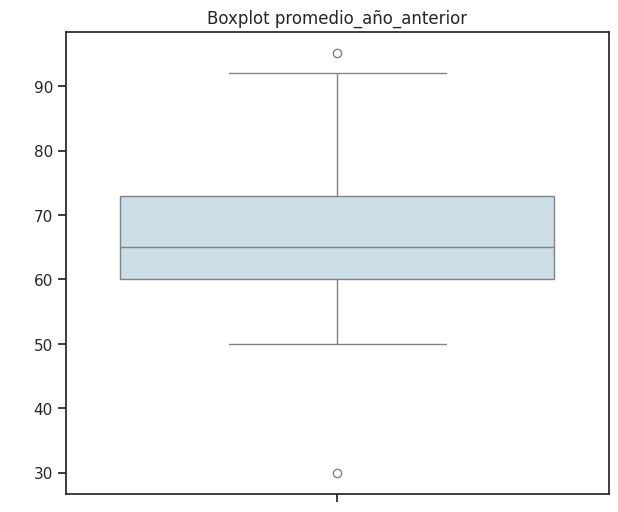

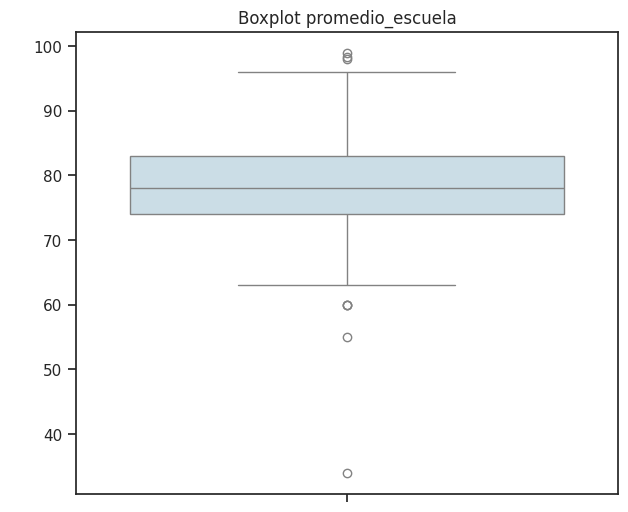

In [15]:
# diagrama de caja para las variables numericas

variables_numericas = ["promedio_año_anterior", "promedio_escuela"]

for var in variables_numericas:
  f, ax = plt.subplots(figsize=(7, 6))
  plt.title(f"Boxplot {var}")
  ax.set(ylabel=" ")
  sns.boxplot(df[var], palette="ch:s=.25,rot=-.25")
plt.show()

In [16]:
# tabla de atipicos

tabla_resumen = []

for var in variables_numericas:

    serie = df[var].dropna()

    # Estadísticos descriptivos
    n = serie.count()
    media = serie.mean()
    std = serie.std()
    minimo = serie.min()
    q1 = serie.quantile(0.25)
    mediana = serie.median()
    q3 = serie.quantile(0.75)
    maximo = serie.max()

    # IQR y límites de Tukey
    IQR = q3 - q1
    limite_inferior = q1 - 1.5 * IQR
    limite_superior = q3 + 1.5 * IQR

    # Conteo de atípicos
    atipicos = serie[(serie < limite_inferior) | (serie > limite_superior)]
    n_atipicos = atipicos.count()
    porcentaje_atipicos = 100 * n_atipicos / n

    tabla_resumen.append([
        var, n, media, std, minimo, q1, mediana, q3, maximo,
        IQR, limite_inferior, limite_superior,
        n_atipicos, porcentaje_atipicos
    ])

columnas = [
    "Variable", "N", "Media", "Desv.Std", "Min", "Q1", "Mediana", "Q3", "Max",
    "IQR", "Límite inferior", "Límite superior",
    "N° Atípicos", "% Atípicos"
]

tabla_resumen = pd.DataFrame(tabla_resumen, columns=columnas)



In [17]:
tabla_resumen.T

,0,1
Variable,promedio_año_anterior,promedio_escuela
N,320,399
Media,66.268469,77.989724
Desv.Std,9.147906,7.048618
Min,30.0,34.0
Q1,60.0,74.0
Mediana,65.0,78.0
Q3,73.0,83.0
Max,95.22,99.0
IQR,13.0,9.0


In [18]:
variables_categoricas = ['genero', 'año_anterior', 'facultad',
                        'alojamiento_2023', 'presupuesto', 'beca',
                        'horas_estudio_semanal', 'fiestas_semanales',
                        'consumo_bebidas_alcoholicas', 'clases_perdidas(alcohol)',
                        'reprobaciones', 'relacion_sentimental',
                        'aprobacion_padres_alcohol','tipo_relacion(padres)']

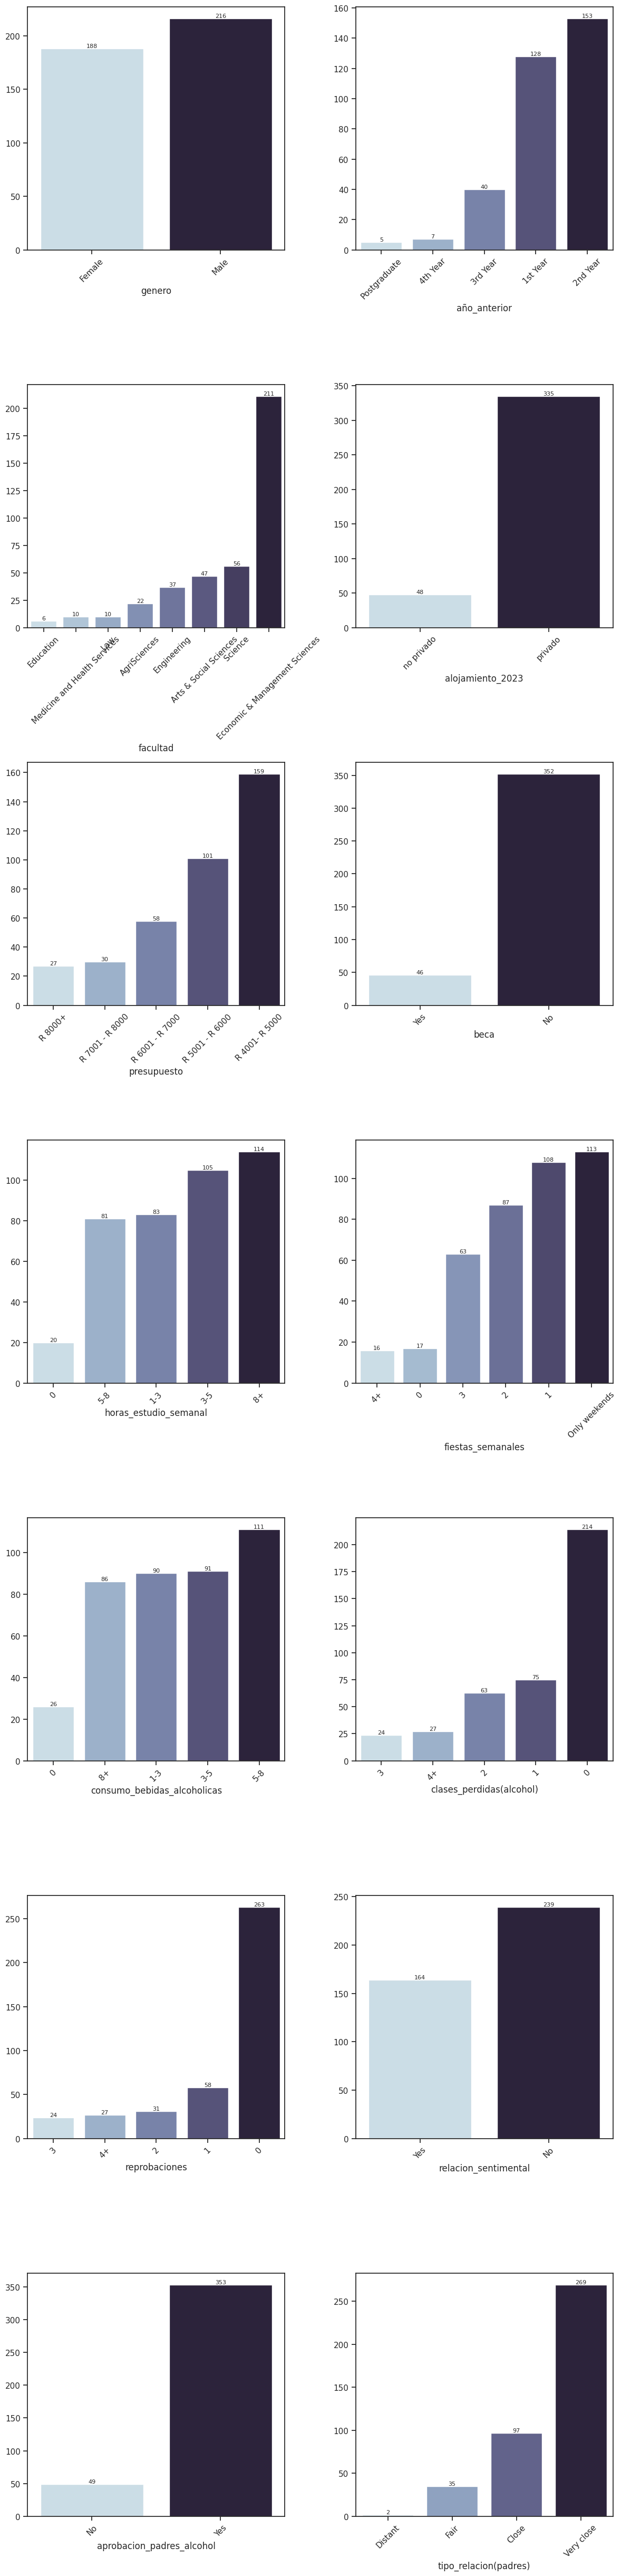

In [19]:
#digrama de barras para cada variable categorica
import math

n_vars = len(variables_categoricas)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 7*n_rows))
axes = axes.flatten()  # para recorrer fácilmente

for i, var in enumerate(variables_categoricas):

    counts = df[var].value_counts().sort_values(ascending=True)

    ax = sns.barplot(
        x=counts.index,
        y=counts.values,
        hue=counts.index,
        palette="ch:s=.25,rot=-.25",
        legend=False,
        errorbar=None,
        ax=axes[i]
    )

    # Etiquetas encima
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    ax.tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()